# **Import** **libraries**

In [3]:
import tensorflow as tf
import numpy as np
import cv2 as cv
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Creating data**

In [4]:
train_real = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection_train/face_real/*.jpg",shuffle=False)
train_fake = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection_train/face_fake/*.jpg",shuffle=False)
validation_real = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection_validation/face_real/*.jpg",shuffle=False)
validation_fake = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection_validation/face_fake/*.jpg",shuffle=False)
test_real = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection_test/face_real/*.jpg",shuffle=False)
test_fake = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection_test/face_fake/*.jpg",shuffle=False)


# **Dataset Preprocessing**

In [5]:
#Reading images on disk and converting them to tensor
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    return img

train_real = train_real.map(load_image)
train_fake = train_fake.map(load_image)

validation_real = validation_real.map(load_image)
validation_fake = validation_fake.map(load_image)

test_real = test_real.map(load_image)
test_fake = test_fake.map(load_image)

In [6]:
#Labeling data and images so that 0 means real and 1 means fake
def add_label(image, label):
    return image, label

train_real = train_real.map(lambda x: add_label(x, 0))
train_fake = train_fake.map(lambda x: add_label(x, 1))

validation_real = validation_real.map(lambda x: add_label(x, 0))
validation_fake = validation_fake.map(lambda x: add_label(x, 1))

test_real = test_real.map(lambda x: add_label(x, 0))
test_fake = test_fake.map(lambda x: add_label(x, 1))

In [7]:
#Mixing fake and real images
train_dataset = train_real.concatenate(train_fake)
validation_dataset = validation_real.concatenate(validation_fake)
test_dataset = test_real.concatenate(test_fake)
#Shuffle images for training
train_dataset = train_dataset.shuffle(6400)

In [8]:
#Preprocessing entire images for model training
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_dataset = train_dataset.map(preprocess)

validation_dataset = validation_dataset.map(preprocess)

test_dataset = test_dataset.map(preprocess)

In [9]:
#Divides images into batch of 32 for training.
BATCH_SIZE = 32
train_dataset = train_dataset.batch(BATCH_SIZE)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

# **Architecture** **design** **and** **model** **learning** **transfer**

In [10]:
base_model = EfficientNetB0(#Using EfficientNetB0 for the base model
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [11]:
#Model architecture for the model
inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = Model(inputs, outputs)

In [12]:
#Compiling and training the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1595s 2s/step - accuracy: 0.5364 - loss: 0.6933 - val_accuracy: 0.5744 - val_loss: 0.6820
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.5508 - loss: 0.6868 - val_accuracy: 0.5919 - val_loss: 0.6798
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.5634 - loss: 0.6820 - val_accuracy: 0.5794 - val_loss: 0.6797
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.5628 - loss: 0.6798 - val_accuracy: 0.5875 - val_loss: 0.6787
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.5788 - loss: 0.6754 - val_accuracy: 0.5756 - val_loss: 0.6796
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.5861 - loss: 0.6710 - val_accuracy: 0.5769 - val_loss: 0.6785
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.5923 - loss: 0.6700 - val_accuracy: 0.5794 - val_loss: 0.6789
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.5855 - loss: 0.6692 - 

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,416 (15.46 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 2,564 (10.02 KB)

# Model evaluation and saving

In [13]:
#Model evaluation on test data
model.evaluate(test_dataset)

63/63 ━━━━━━━━━━━━━━━━━━━━ 619s 10s/step - accuracy: 0.6045 - loss: 0.6663


[0.6662641763687134, 0.6044999957084656]

In [15]:
#Save the best model.
model.save("/content/drive/MyDrive/efficientnet_stage3.keras")

# **Visual display of modeled parameters**

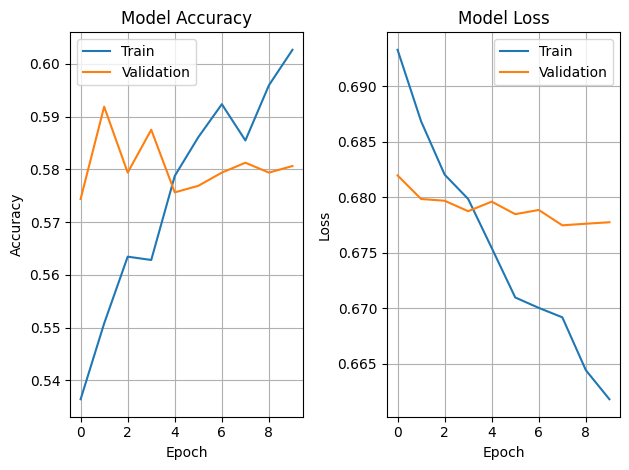

In [16]:
#Graphical display of the most accurate model and model validation accuracy on each epoch
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
#Show the model loss diagram for training and validation
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
#Model evaluation on the test dataset
y_true = []
y_pred_prob = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred_prob.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

y_pred = (y_pred_prob >= 0.5).astype(int)

In [18]:
#The values ​​of a set of parameters on the model test
print(f"Accuracy : {accuracy_score(y_true,y_pred):.4f}")
print(f"Precision: {precision_score(y_true,y_pred):.4f}")
print(f"Recall   : {recall_score(y_true,y_pred):.4f}")
print(f"F1-Score : {f1_score(y_true,y_pred):.4f}")

Accuracy : 0.6045
Precision: 0.5822
Recall   : 0.7400
F1-Score : 0.6517


In [19]:
print(classification_report(y_true,y_pred,target_names=["Real","Fake"]))

              precision    recall  f1-score   support

        Real       0.64      0.47      0.54      1000
        Fake       0.58      0.74      0.65      1000

    accuracy                           0.60      2000
   macro avg       0.61      0.60      0.60      2000
weighted avg       0.61      0.60      0.60      2000



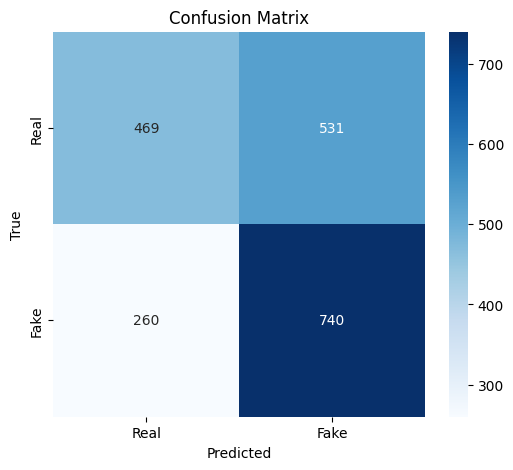

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real","Fake"],
    yticklabels=["Real","Fake"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

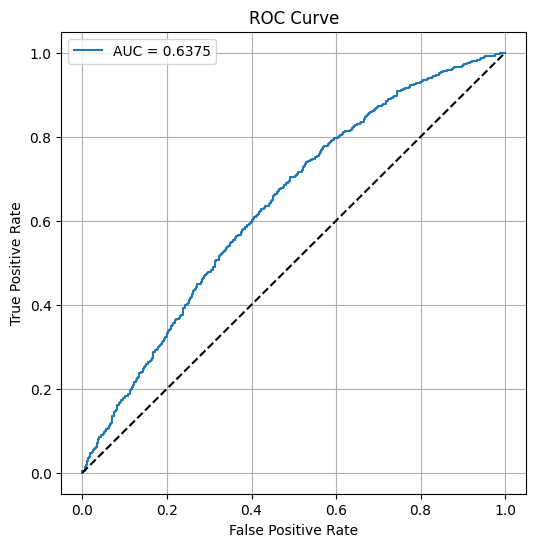

AUC Score: 0.6375


In [21]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")